# Visualize the DCRNN Traffic-Signal Graph

Use this notebook to build the same graph topology used by the DCRNN-based experiments and visualize it on top of the SUMO road network.

## What this notebook does

1. Loads one scenario config from `configs/scenario/`.
2. Builds the graph observation wrapper used by the DCRNN path.
3. Extracts the adjacency matrix and directed edge list.
4. Draws the graph over the SUMO map and shows the adjacency heatmap.

This notebook uses the repo's current `build_traffic_signal_graph(...)` logic, so the picture should match the DCRNN topology actually seen by training.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import sumolib
from matplotlib.patches import FancyArrowPatch
from omegaconf import OmegaConf

try:
    import pandas as pd
except ImportError:
    pd = None


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "sumo_rl").exists() and (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Could not locate the repo root from the current working directory.")


ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from sumo_rl.environment.graph_env import build_graph_parallel_env, resolve_sumo_base_env

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = False

print(f"Repo root: {ROOT}")
print(f"pandas available: {pd is not None}")

c:\Users\PC\Desktop\Bai_lam_Nhat_Minh\VGU\Thesis\Code\sumo-rl\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-06-28 21:18:34,058	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-06-28 21:18:46,280	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Repo root: C:\Users\PC\Desktop\Bai_lam_Nhat_Minh\VGU\Thesis\Code\sumo-rl
pandas available: True


In [2]:
SCENARIO_NAME = "resco_ingolstadt7"
HISTORY_LEN = 5
INCLUDE_VIRTUAL_NODES = True
DISPLAY_VIRTUAL_NODES = False
ADD_SELF_LOOPS = True
SHOW_SELF_LOOPS = False
MAP_FIGSIZE = (12, 10)
ADJ_FIGSIZE = (10, 9)
MAP_LABEL_FONT_SIZE = 11
MAP_TITLE_FONT_SIZE = 15
ADJ_TICK_FONT_SIZE = 11
ADJ_TITLE_FONT_SIZE = 15
COLORBAR_TICK_FONT_SIZE = 10
EXPORT_DPI = 300
SAVE_FIGURES = False
OUTPUT_DIR = ROOT / "experiments" / "artifacts" / "graph_viz"

QUEUE_DIAGNOSTIC_JUNCTION = "gneJ143"
QUEUE_REPLACEMENT_EDGE = "10425609#0"
QUEUE_SHORT_EDGE = "10425609#1"
QUEUE_APPROACH_LANE_INDICES = [1, 2, 3]

SCENARIO_NAME

'resco_ingolstadt21'

In [3]:
def load_cfg(scenario_name: str):
    base_cfg = OmegaConf.load(ROOT / "configs" / "base.yaml")
    scenario_cfg = OmegaConf.load(ROOT / "configs" / "scenario" / f"{scenario_name}.yaml")
    cfg = OmegaConf.merge(base_cfg, scenario_cfg)
    cfg.experiment.name = f"notebook_{scenario_name}_graph"
    return cfg


def resolve_repo_path(raw_path: str | Path) -> Path:
    path = Path(str(raw_path))
    if path.is_absolute():
        return path
    text = str(raw_path).replace("\\", "/")
    if text.startswith("sumo_rl/"):
        return ROOT / text
    return ROOT / path


def lane_shape_points(net, lane_ids):
    points = []
    for lane_id in lane_ids:
        try:
            lane = net.getLane(str(lane_id))
            points.extend((float(x), float(y)) for x, y in lane.getShape())
        except Exception:
            continue
    return points


def mean_point(points):
    if not points:
        return None
    return (
        sum(point[0] for point in points) / len(points),
        sum(point[1] for point in points) / len(points),
    )


def traffic_signal_positions(net, base_env, ts_ids):
    positions = {}
    traffic_signals = getattr(base_env, "traffic_signals", {}) or {}
    for ts_id in ts_ids:
        try:
            x, y = net.getNode(str(ts_id)).getCoord()
            positions[str(ts_id)] = (float(x), float(y))
            continue
        except Exception:
            pass

        signal = traffic_signals.get(str(ts_id))
        if signal is None:
            continue
        lane_ids = list(getattr(signal, "lanes", []) or []) + list(getattr(signal, "out_lanes", []) or [])
        center = mean_point(lane_shape_points(net, lane_ids))
        if center is not None:
            positions[str(ts_id)] = center
    return positions


def edge_shapes(net):
    shapes = []
    for edge in net.getEdges():
        try:
            shape = [(float(x), float(y)) for x, y in edge.getShape()]
        except Exception:
            shape = []
        if len(shape) >= 2:
            shapes.append(shape)
    return shapes


def add_virtual_node_positions(graph, positions):
    real_points = [positions[ts_id] for ts_id in graph.ts_ids if ts_id in positions]
    if not real_points:
        return positions
    min_x = min(point[0] for point in real_points)
    max_x = max(point[0] for point in real_points)
    center_y = sum(point[1] for point in real_points) / len(real_points)
    span_x = max(max_x - min_x, 1.0)
    if graph.incoming_node_index is not None:
        positions["__incoming__"] = (min_x - 0.20 * span_x, center_y)
    if graph.outgoing_node_index is not None:
        positions["__outgoing__"] = (max_x + 0.20 * span_x, center_y)
    return positions


def node_labels(graph, *, include_virtual_nodes=True):
    labels = list(graph.ts_ids)
    if include_virtual_nodes and graph.incoming_node_index is not None:
        labels.append("IN")
    if include_virtual_nodes and graph.outgoing_node_index is not None:
        labels.append("OUT")
    return labels


def node_display_labels(graph, *, include_virtual_nodes=True):
    labels = []
    for index, ts_id in enumerate(graph.ts_ids, start=1):
        if str(ts_id).startswith("cluster_") or str(ts_id).startswith("GS_"):
            labels.append(f"TS{index}")
        else:
            labels.append(str(ts_id))
    if include_virtual_nodes and graph.incoming_node_index is not None:
        labels.append("IN")
    if include_virtual_nodes and graph.outgoing_node_index is not None:
        labels.append("OUT")
    return labels


def visible_node_indices(graph, *, include_virtual_nodes=True):
    indices = [int(index) for index in range(len(graph.ts_ids))]
    if include_virtual_nodes and graph.incoming_node_index is not None:
        indices.append(int(graph.incoming_node_index))
    if include_virtual_nodes and graph.outgoing_node_index is not None:
        indices.append(int(graph.outgoing_node_index))
    return indices


def node_label_rows(graph, *, include_virtual_nodes=True):
    raw_labels = node_labels(graph, include_virtual_nodes=include_virtual_nodes)
    display_labels = node_display_labels(graph, include_virtual_nodes=include_virtual_nodes)
    rows = []
    for index, (raw_label, display_label) in enumerate(zip(raw_labels, display_labels)):
        rows.append(
            {
                "node_index": index,
                "display_label": display_label,
                "node_id": raw_label,
            }
        )
    return rows


def graph_edge_rows(graph, *, include_virtual_nodes=True):
    visible_indices = set(visible_node_indices(graph, include_virtual_nodes=include_virtual_nodes))
    labels = node_display_labels(graph, include_virtual_nodes=include_virtual_nodes)
    label_by_index = dict(zip(sorted(visible_indices), labels))
    rows = []
    for source, target in np.argwhere(graph.adjacency > 0):
        source = int(source)
        target = int(target)
        if source not in visible_indices or target not in visible_indices:
            continue
        rows.append(
            {
                "source_index": source,
                "target_index": target,
                "source": label_by_index[source],
                "target": label_by_index[target],
                "is_self_loop": bool(source == target),
            }
        )
    return rows


def display_adjacency(graph, *, include_virtual_nodes=True):
    indices = visible_node_indices(graph, include_virtual_nodes=include_virtual_nodes)
    return graph.adjacency[np.ix_(indices, indices)]


def lane_ids_for_edge(edge_id: str, lane_indices: list[int] | None = None) -> list[str]:
    if lane_indices is None:
        return [lane.getID() for lane in net.getEdge(edge_id).getLanes()]
    return [f"{edge_id}_{lane_index}" for lane_index in lane_indices]


def lane_summary_rows(net, lane_ids: list[str]) -> list[dict]:
    rows = []
    for lane_id in lane_ids:
        try:
            lane = net.getLane(str(lane_id))
            edge = lane.getEdge()
            rows.append(
                {
                    "lane_id": lane.getID(),
                    "edge_id": edge.getID(),
                    "index": int(lane.getIndex()),
                    "length_m": float(lane.getLength()),
                    "from_node": edge.getFromNode().getID(),
                    "to_node": edge.getToNode().getID(),
                    "exists": True,
                }
            )
        except Exception as exc:
            rows.append(
                {
                    "lane_id": str(lane_id),
                    "edge_id": "",
                    "index": "",
                    "length_m": float("nan"),
                    "from_node": "",
                    "to_node": "",
                    "exists": False,
                    "error": str(exc),
                }
            )
    return rows


def predecessor_edge_rows(net, edge_id: str) -> list[dict]:
    edge = net.getEdge(edge_id)
    from_node = edge.getFromNode()
    rows = []
    for incoming in from_node.getIncoming():
        rows.append(
            {
                "edge_id": incoming.getID(),
                "lane_ids": [lane.getID() for lane in incoming.getLanes()],
                "lane_count": len(incoming.getLanes()),
                "lengths_m": [float(lane.getLength()) for lane in incoming.getLanes()],
                "from_node": incoming.getFromNode().getID(),
                "to_node": incoming.getToNode().getID(),
            }
        )
    return rows


def plot_highlighted_lanes(net, road_shapes, lane_groups: dict[str, list[str]], *, title: str, figsize=(8, 8)):
    fig, ax = plt.subplots(figsize=figsize)
    for shape in road_shapes:
        xs = [point[0] for point in shape]
        ys = [point[1] for point in shape]
        ax.plot(xs, ys, color="#cbd5e1", linewidth=0.8, alpha=0.45, zorder=1)

    colors = ["#ef4444", "#2563eb", "#16a34a", "#9333ea", "#f97316"]
    plotted_points = []
    for group_index, (label, lane_ids) in enumerate(lane_groups.items()):
        color = colors[group_index % len(colors)]
        for lane_id in lane_ids:
            try:
                lane = net.getLane(str(lane_id))
            except Exception:
                continue
            shape = [(float(x), float(y)) for x, y in lane.getShape()]
            if len(shape) < 2:
                continue
            plotted_points.extend(shape)
            xs = [point[0] for point in shape]
            ys = [point[1] for point in shape]
            ax.plot(xs, ys, color=color, linewidth=4.0, alpha=0.95, zorder=4)
            mid = shape[len(shape) // 2]
            ax.text(mid[0], mid[1], lane_id, color=color, fontsize=8, zorder=5)
        ax.plot([], [], color=color, linewidth=4.0, label=label)

    if QUEUE_DIAGNOSTIC_JUNCTION in positions:
        x, y = positions[QUEUE_DIAGNOSTIC_JUNCTION]
        plotted_points.append((x, y))
        ax.scatter([x], [y], s=90, color="#111827", marker="x", zorder=6, label=QUEUE_DIAGNOSTIC_JUNCTION)

    if plotted_points:
        xs = [point[0] for point in plotted_points]
        ys = [point[1] for point in plotted_points]
        pad = max(max(xs) - min(xs), max(ys) - min(ys), 20.0) * 0.35
        ax.set_xlim(min(xs) - pad, max(xs) + pad)
        ax.set_ylim(min(ys) - pad, max(ys) + pad)

    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title)
    ax.legend(loc="best")
    plt.show()
    return fig, ax

In [4]:
try:
    graph_env.close()
except Exception:
    pass

cfg = load_cfg(SCENARIO_NAME)
params = {
    "history_len": HISTORY_LEN,
    "include_virtual_nodes": INCLUDE_VIRTUAL_NODES,
    "add_self_loops": ADD_SELF_LOOPS,
}
graph_env = build_graph_parallel_env(
    cfg,
    ROOT / "outputs" / "_notebooks",
    seed=int(cfg.experiment.seed),
    params=params,
    use_libsumo=False,
)
base_env = resolve_sumo_base_env(graph_env)
graph = graph_env.graph
net_file = resolve_repo_path(cfg.env.kwargs.net_file)
net = sumolib.net.readNet(str(net_file))
road_shapes = edge_shapes(net)
positions = add_virtual_node_positions(
    graph,
    traffic_signal_positions(net, base_env, list(graph.ts_ids)),
)
edge_rows = graph_edge_rows(graph, include_virtual_nodes=DISPLAY_VIRTUAL_NODES)
label_rows = node_label_rows(graph, include_virtual_nodes=DISPLAY_VIRTUAL_NODES)

print(f"Scenario: {SCENARIO_NAME}")
print(f"Net file: {net_file}")
print(f"Traffic-signal nodes: {len(graph.ts_ids)}")
print(f"Graph nodes total: {graph.num_nodes}")
print(f"Directed edges (including self loops): {int(graph.adjacency.sum())}")
print(f"Feature dim per node: {graph.feature_dim}")

Scenario: resco_ingolstadt21
Net file: C:\Users\PC\Desktop\Bai_lam_Nhat_Minh\VGU\Thesis\Code\sumo-rl\sumo_rl\nets\RESCO\ingolstadt21\ingolstadt21.net.xml
Traffic-signal nodes: 21
Graph nodes total: 21
Directed edges (including self loops): 67
Feature dim per node: 33


## gneJ143 Queue Segment Diagnostic

Use these cells to verify whether the visible phase-2 queue fits inside the diagnostic replacement edge or spills into predecessor edges.


In [ ]:
phase2_replacement_lanes = lane_ids_for_edge(QUEUE_REPLACEMENT_EDGE, QUEUE_APPROACH_LANE_INDICES)
phase2_short_lanes = lane_ids_for_edge(QUEUE_SHORT_EDGE, QUEUE_APPROACH_LANE_INDICES)
phase2_all_lanes = phase2_replacement_lanes + phase2_short_lanes

print(f"Diagnostic junction: {QUEUE_DIAGNOSTIC_JUNCTION}")
print(f"Replacement upstream edge: {QUEUE_REPLACEMENT_EDGE}")
print(f"Original short edge: {QUEUE_SHORT_EDGE}")
print("Replacement lanes:", phase2_replacement_lanes)
print("Short-edge lanes:", phase2_short_lanes)

lane_rows = lane_summary_rows(net, phase2_all_lanes)
if pd is not None:
    display(pd.DataFrame(lane_rows))
else:
    for row in lane_rows:
        print(row)

predecessor_rows = predecessor_edge_rows(net, QUEUE_REPLACEMENT_EDGE)
print(f"\nIncoming predecessor edges before {QUEUE_REPLACEMENT_EDGE}:")
if pd is not None:
    display(pd.DataFrame(predecessor_rows))
else:
    for row in predecessor_rows:
        print(row)


In [ ]:
predecessor_lane_groups = {
    f"predecessor {row['edge_id']}": row["lane_ids"]
    for row in predecessor_edge_rows(net, QUEUE_REPLACEMENT_EDGE)
}

lane_groups = {
    f"replacement {QUEUE_REPLACEMENT_EDGE}": phase2_replacement_lanes,
    f"short edge {QUEUE_SHORT_EDGE}": phase2_short_lanes,
    **predecessor_lane_groups,
}

plot_highlighted_lanes(
    net,
    road_shapes,
    lane_groups,
    title=f"{QUEUE_DIAGNOSTIC_JUNCTION} phase-2 queue segment check",
    figsize=(9, 9),
)


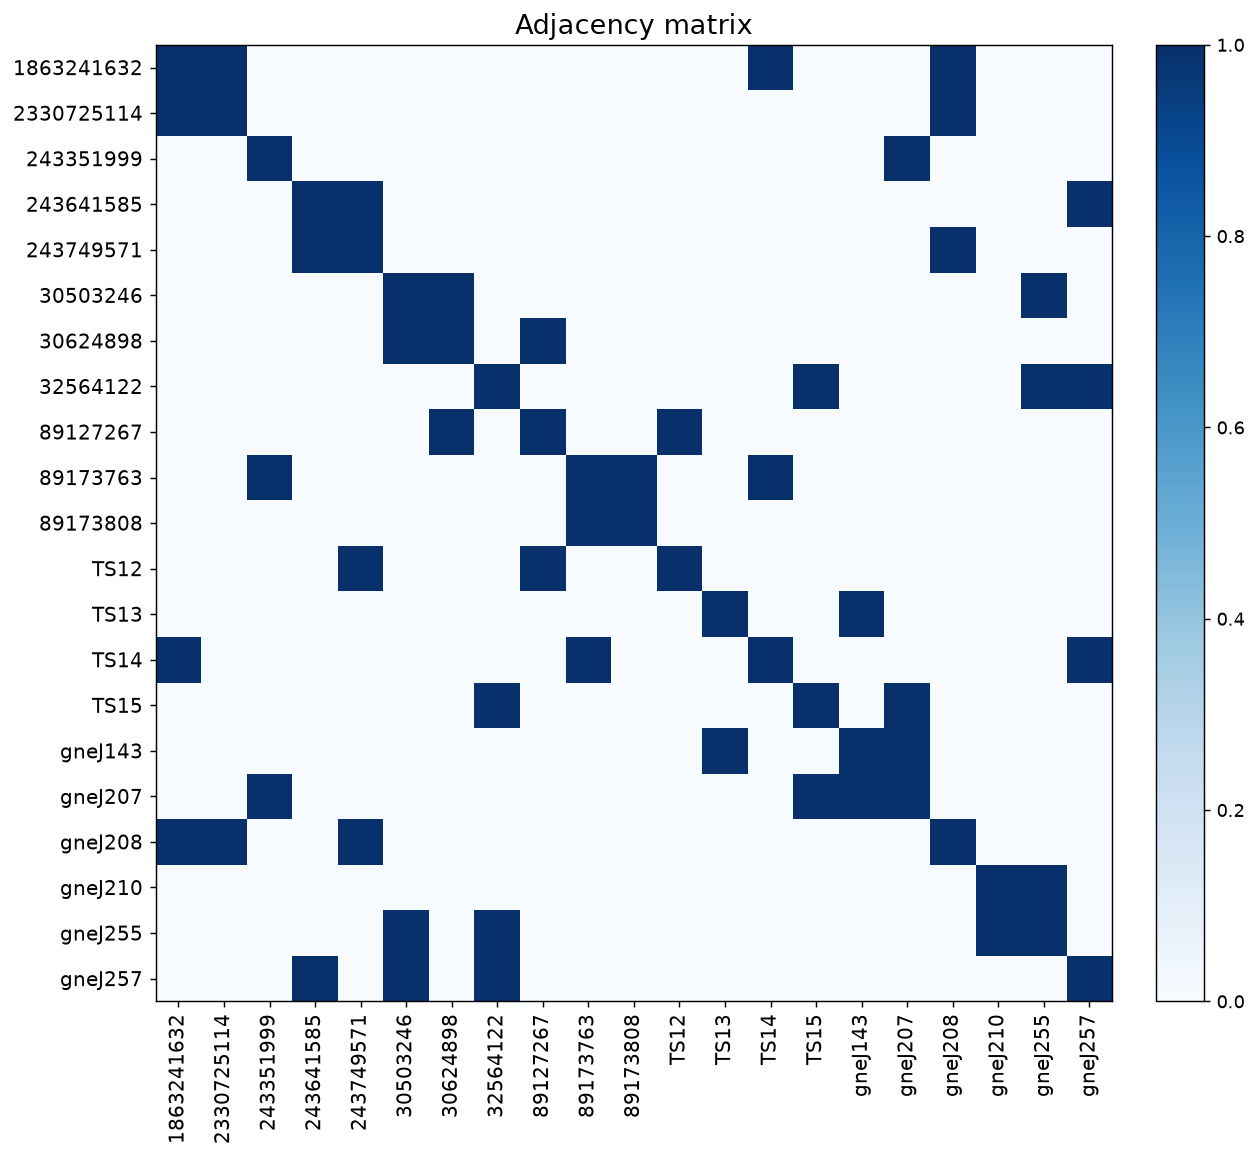

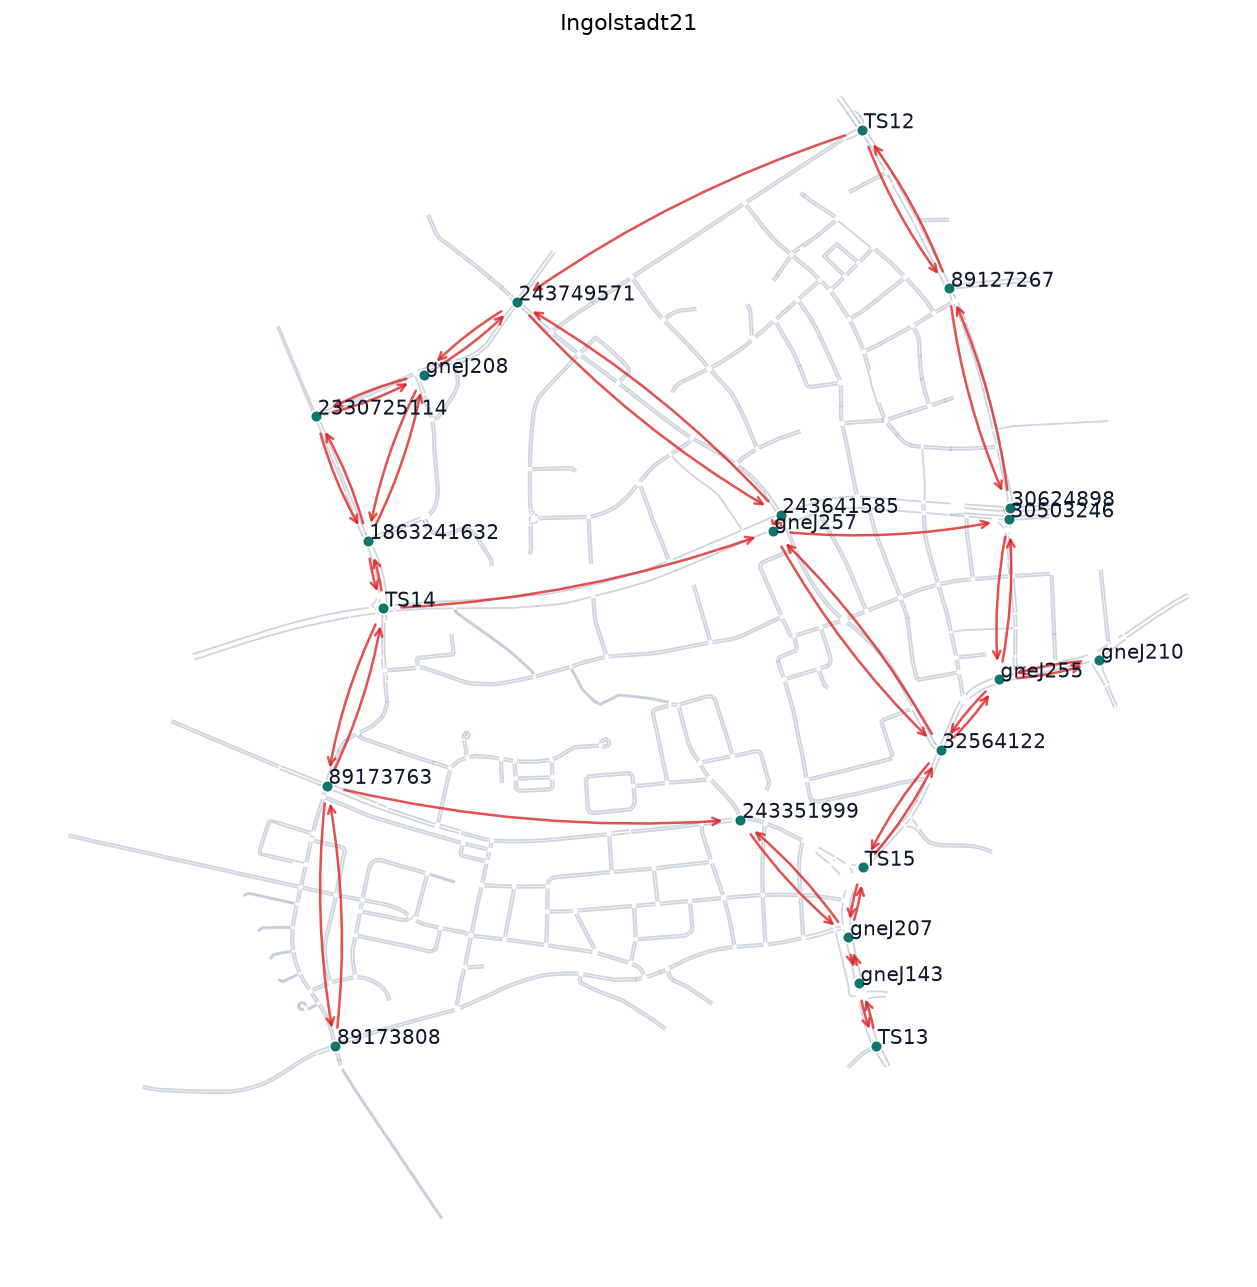

<Figure size 832x624 with 0 Axes>

In [5]:
labels = node_display_labels(graph, include_virtual_nodes=DISPLAY_VIRTUAL_NODES)
visible_indices = visible_node_indices(graph, include_virtual_nodes=DISPLAY_VIRTUAL_NODES)
index_to_point = {}
for ts_id, index in graph.ts_index.items():
    if ts_id in positions:
        index_to_point[int(index)] = positions[ts_id]
if DISPLAY_VIRTUAL_NODES and graph.incoming_node_index is not None and "__incoming__" in positions:
    index_to_point[int(graph.incoming_node_index)] = positions["__incoming__"]
if DISPLAY_VIRTUAL_NODES and graph.outgoing_node_index is not None and "__outgoing__" in positions:
    index_to_point[int(graph.outgoing_node_index)] = positions["__outgoing__"]

fig_map, ax_map = plt.subplots(figsize=MAP_FIGSIZE)

for shape in road_shapes:
    xs = [point[0] for point in shape]
    ys = [point[1] for point in shape]
    ax_map.plot(xs, ys, color="#94a3b8", linewidth=1.0, alpha=0.45, zorder=1)

for source, target in np.argwhere(graph.adjacency > 0):
    source = int(source)
    target = int(target)
    if source not in visible_indices or target not in visible_indices:
        continue
    if source == target and not SHOW_SELF_LOOPS:
        continue
    if source not in index_to_point or target not in index_to_point:
        continue
    start = index_to_point[source]
    end = index_to_point[target]
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="->",
        mutation_scale=10,
        linewidth=1.4,
        color="#dc2626",
        alpha=0.80,
        shrinkA=10,
        shrinkB=10,
        zorder=2,
        connectionstyle="arc3,rad=0.08" if source != target else "arc3,rad=0.35",
    )
    ax_map.add_patch(arrow)

for index, label in enumerate(labels):
    if index not in index_to_point:
        continue
    x, y = index_to_point[index]
    is_virtual = label in {"IN", "OUT"}
    face = "#0f766e" if not is_virtual else "#7c3aed"
    size = 42 if not is_virtual else 56
    ax_map.scatter([x], [y], s=size, color=face, edgecolors="white", linewidths=0.9, zorder=3)
    ax_map.text(x + 4, y + 4, label, fontsize=MAP_LABEL_FONT_SIZE, color="#0f172a", zorder=4)

ax_map.set_title(f"{SCENARIO_NAME.split('_')[1].capitalize()}")
ax_map.set_aspect("equal", adjustable="box")
ax_map.axis("off")

fig_map.tight_layout()

fig_adj, ax_adj = plt.subplots(figsize=ADJ_FIGSIZE)
image = ax_adj.imshow(display_adjacency(graph, include_virtual_nodes=DISPLAY_VIRTUAL_NODES), cmap="Blues", interpolation="nearest")
ax_adj.set_title("Adjacency matrix", fontsize=ADJ_TITLE_FONT_SIZE)
ax_adj.set_xticks(range(len(labels)))
ax_adj.set_yticks(range(len(labels)))
ax_adj.set_xticklabels(labels, rotation=90, fontsize=ADJ_TICK_FONT_SIZE)
ax_adj.set_yticklabels(labels, fontsize=ADJ_TICK_FONT_SIZE)
colorbar = fig_adj.colorbar(image, ax=ax_adj, fraction=0.046, pad=0.04)
colorbar.ax.tick_params(labelsize=COLORBAR_TICK_FONT_SIZE)

fig_adj.tight_layout()

if SAVE_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    map_stem = f"{SCENARIO_NAME}_dcrnn_graph_map"
    adj_stem = f"{SCENARIO_NAME}_dcrnn_graph_adjacency"
    fig_map.savefig(OUTPUT_DIR / f"{map_stem}.png", dpi=EXPORT_DPI, bbox_inches="tight")
    fig_adj.savefig(OUTPUT_DIR / f"{adj_stem}.png", dpi=EXPORT_DPI, bbox_inches="tight")
    print(f"Saved figures under {OUTPUT_DIR}")

plt.figure(fig_map.number)
plt.show()
plt.figure(fig_adj.number)
plt.show()

In [6]:
if pd is not None:
    display(pd.DataFrame(label_rows))
    pd.DataFrame(edge_rows)
else:
    {"labels": label_rows[:10], "edges": edge_rows[:10]}

,node_index,display_label,node_id
0,0,1863241632,1863241632
1,1,2330725114,2330725114
2,2,243351999,243351999
3,3,243641585,243641585
4,4,243749571,243749571
5,5,30503246,30503246
6,6,30624898,30624898
7,7,32564122,32564122
8,8,89127267,89127267
9,9,89173763,89173763


In [11]:
def plot_graph_and_adjacency(graph, positions, scenario_name, *, display_virtual_nodes=False, title_suffix=""):
    labels = node_display_labels(graph, include_virtual_nodes=display_virtual_nodes)
    visible_indices = visible_node_indices(graph, include_virtual_nodes=display_virtual_nodes)
    index_to_point = {}
    for ts_id, index in graph.ts_index.items():
        if ts_id in positions:
            index_to_point[int(index)] = positions[ts_id]
    if display_virtual_nodes and graph.incoming_node_index is not None and "__incoming__" in positions:
        index_to_point[int(graph.incoming_node_index)] = positions["__incoming__"]
    if display_virtual_nodes and graph.outgoing_node_index is not None and "__outgoing__" in positions:
        index_to_point[int(graph.outgoing_node_index)] = positions["__outgoing__"]

    fig_map, ax_map = plt.subplots(figsize=MAP_FIGSIZE)
    for shape in road_shapes:
        xs = [point[0] for point in shape]
        ys = [point[1] for point in shape]
        ax_map.plot(xs, ys, color="#94a3b8", linewidth=1.0, alpha=0.45, zorder=1)

    for source, target in np.argwhere(graph.adjacency > 0):
        source = int(source)
        target = int(target)
        if source not in visible_indices or target not in visible_indices:
            continue
        if source == target and not SHOW_SELF_LOOPS:
            continue
        if source not in index_to_point or target not in index_to_point:
            continue
        start = index_to_point[source]
        end = index_to_point[target]
        arrow = FancyArrowPatch(
            start,
            end,
            arrowstyle="->",
            mutation_scale=10,
            linewidth=1.4,
            color="#dc2626",
            alpha=0.80,
            shrinkA=10,
            shrinkB=10,
            zorder=2,
            connectionstyle="arc3,rad=0.08" if source != target else "arc3,rad=0.35",
        )
        ax_map.add_patch(arrow)

    for label, index in zip(labels, visible_indices):
        if index not in index_to_point:
            continue
        x, y = index_to_point[index]
        is_virtual = label in {"IN", "OUT"}
        face = "#0f766e" if not is_virtual else "#7c3aed"
        size = 42 if not is_virtual else 56
        ax_map.scatter([x], [y], s=size, color=face, edgecolors="white", linewidths=0.9, zorder=3)
        ax_map.text(x + 4, y + 4, label, fontsize=MAP_LABEL_FONT_SIZE, color="#0f172a", zorder=4)

    title = f"{scenario_name.split('_')[1].capitalize()}"
    if title_suffix:
        title = f"{title} {title_suffix}"
    ax_map.set_title(title, fontsize=MAP_TITLE_FONT_SIZE)
    ax_map.set_aspect("equal", adjustable="box")
    ax_map.axis("off")
    fig_map.tight_layout()

    fig_adj, ax_adj = plt.subplots(figsize=ADJ_FIGSIZE)
    image = ax_adj.imshow(display_adjacency(graph, include_virtual_nodes=display_virtual_nodes), cmap="Blues", interpolation="nearest")
    ax_adj.set_title(f"Adjacency matrix{title_suffix}", fontsize=ADJ_TITLE_FONT_SIZE)
    ax_adj.set_xticks(range(len(labels)))
    ax_adj.set_yticks(range(len(labels)))
    ax_adj.set_xticklabels(labels, rotation=90, fontsize=ADJ_TICK_FONT_SIZE)
    ax_adj.set_yticklabels(labels, fontsize=ADJ_TICK_FONT_SIZE)
    colorbar = fig_adj.colorbar(image, ax=ax_adj, fraction=0.046, pad=0.04)
    colorbar.ax.tick_params(labelsize=COLORBAR_TICK_FONT_SIZE)
    fig_adj.tight_layout()

    plt.figure(fig_map.number)
    plt.show()
    plt.figure(fig_adj.number)
    plt.show()

    return fig_map, fig_adj

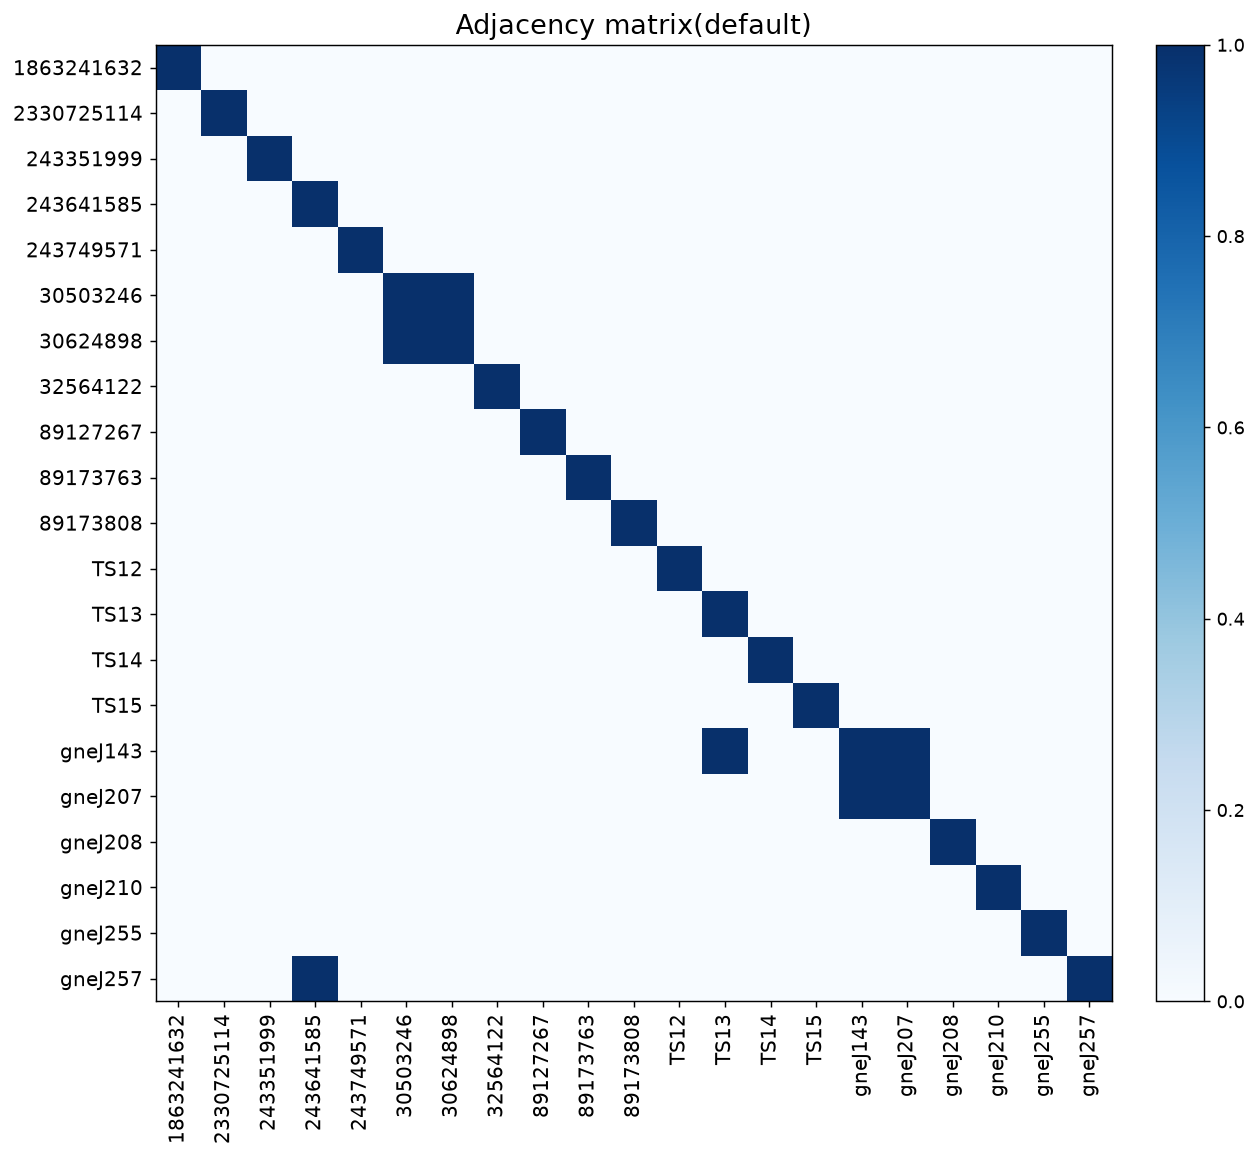

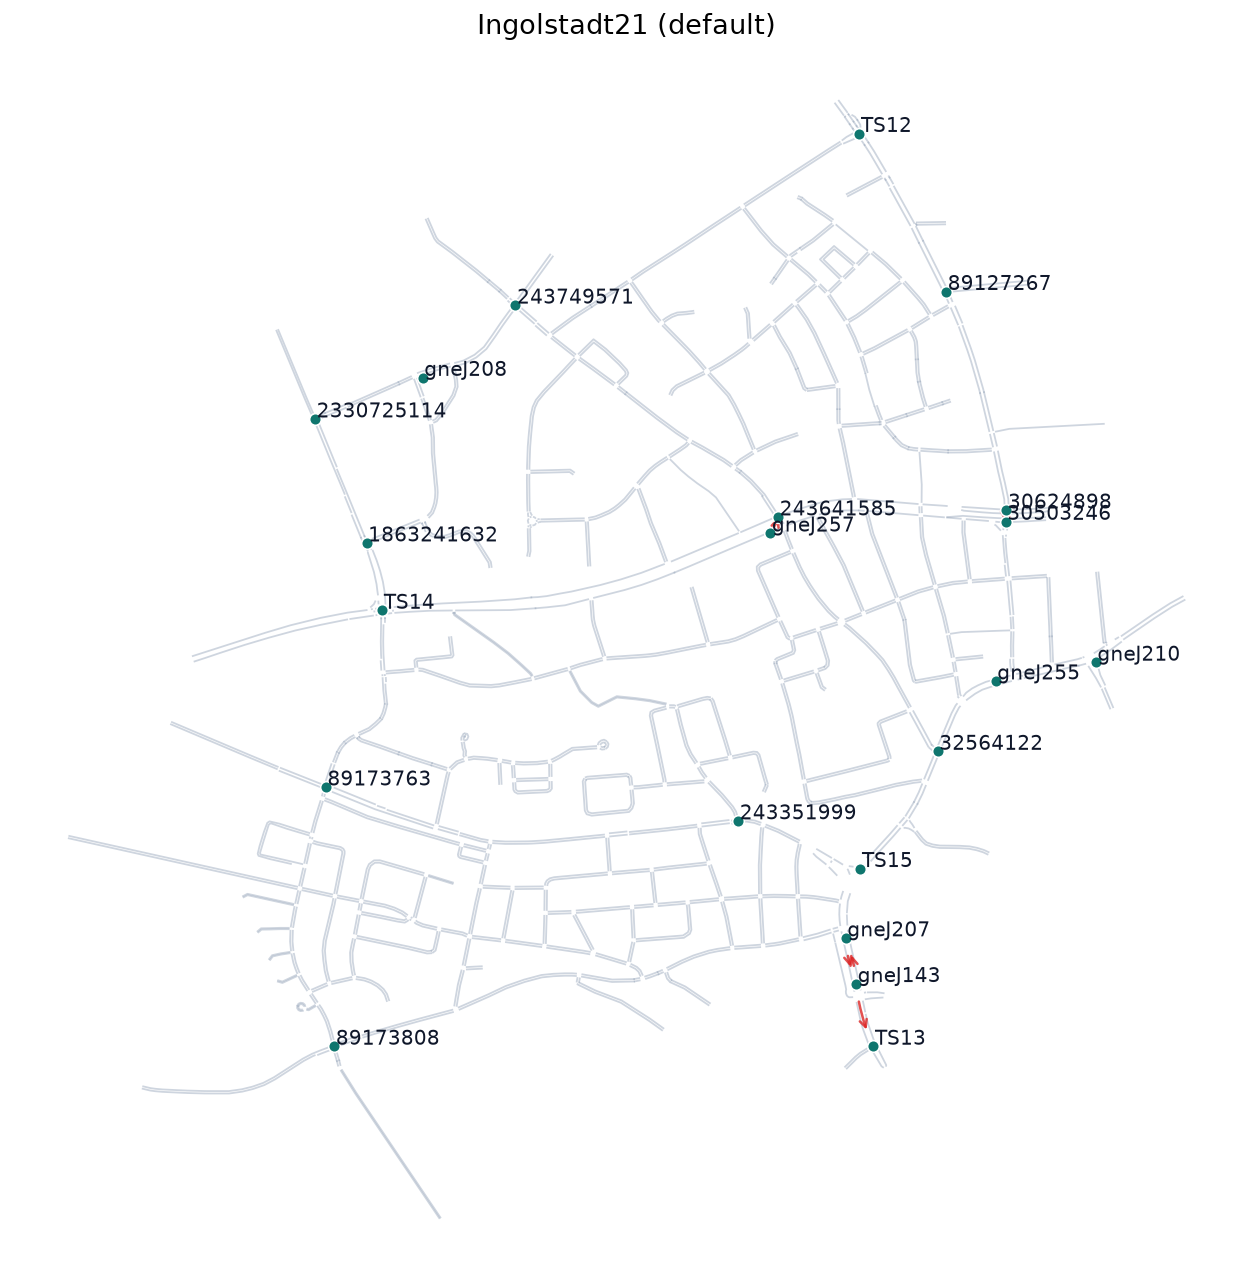

<Figure size 832x624 with 0 Axes>

(<Figure size 1560x1300 with 1 Axes>, <Figure size 1300x1170 with 2 Axes>)

In [12]:
# Plot the current default graph constructor and its adjacency matrix.
default_positions = add_virtual_node_positions(
    graph,
    traffic_signal_positions(net, base_env, list(graph.ts_ids)),
)
plot_graph_and_adjacency(
    graph,
    default_positions,
    SCENARIO_NAME,
    display_virtual_nodes=DISPLAY_VIRTUAL_NODES,
    title_suffix="(default)",
)


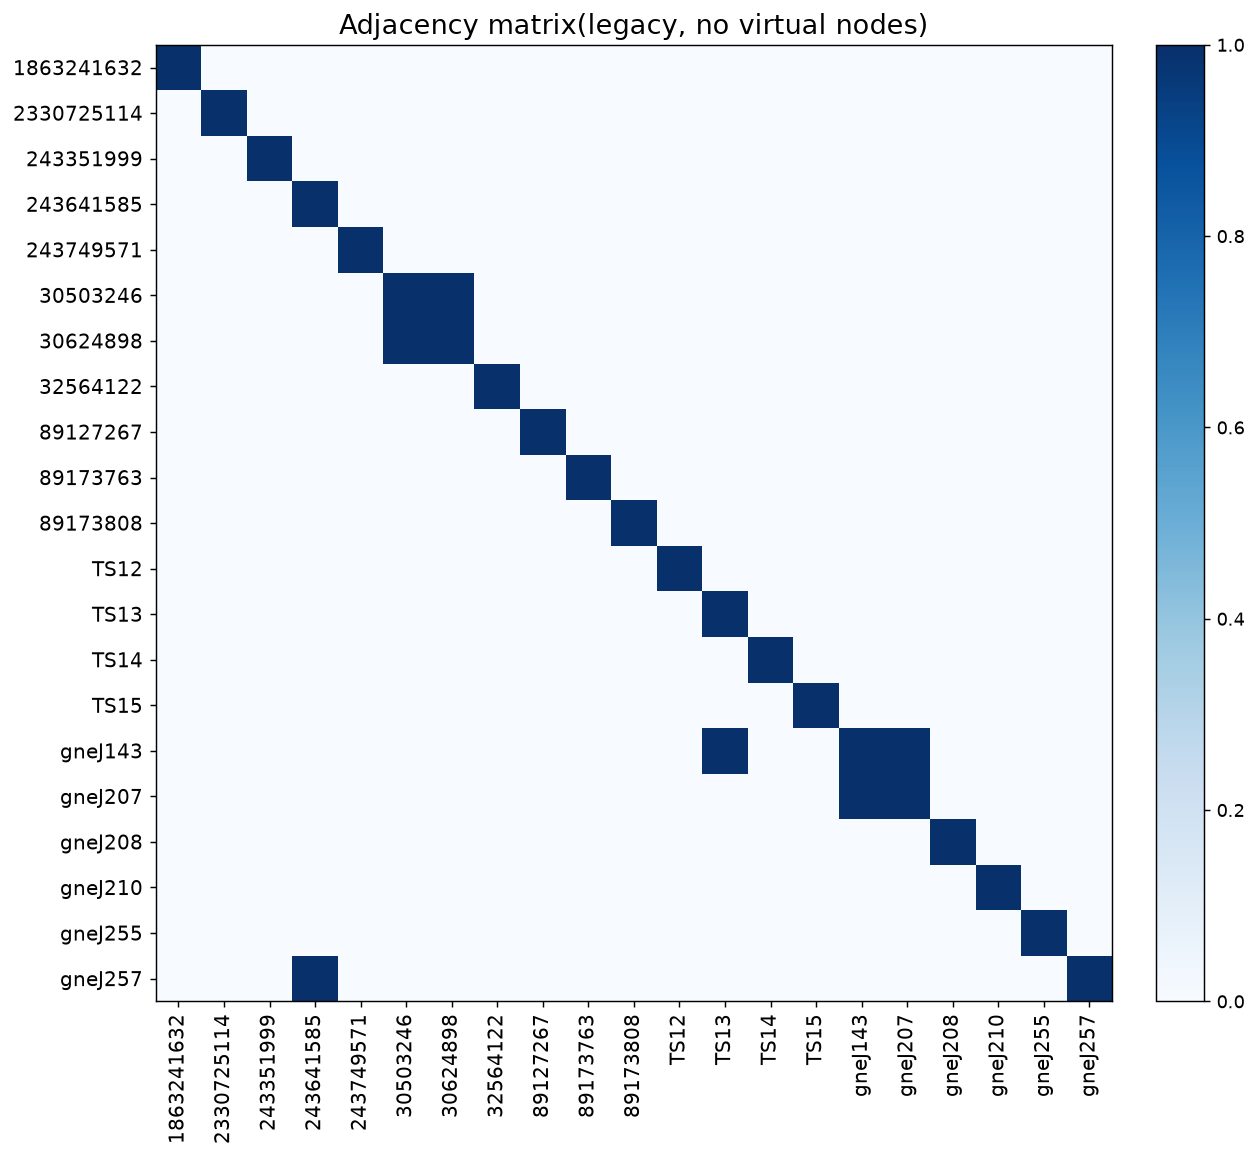

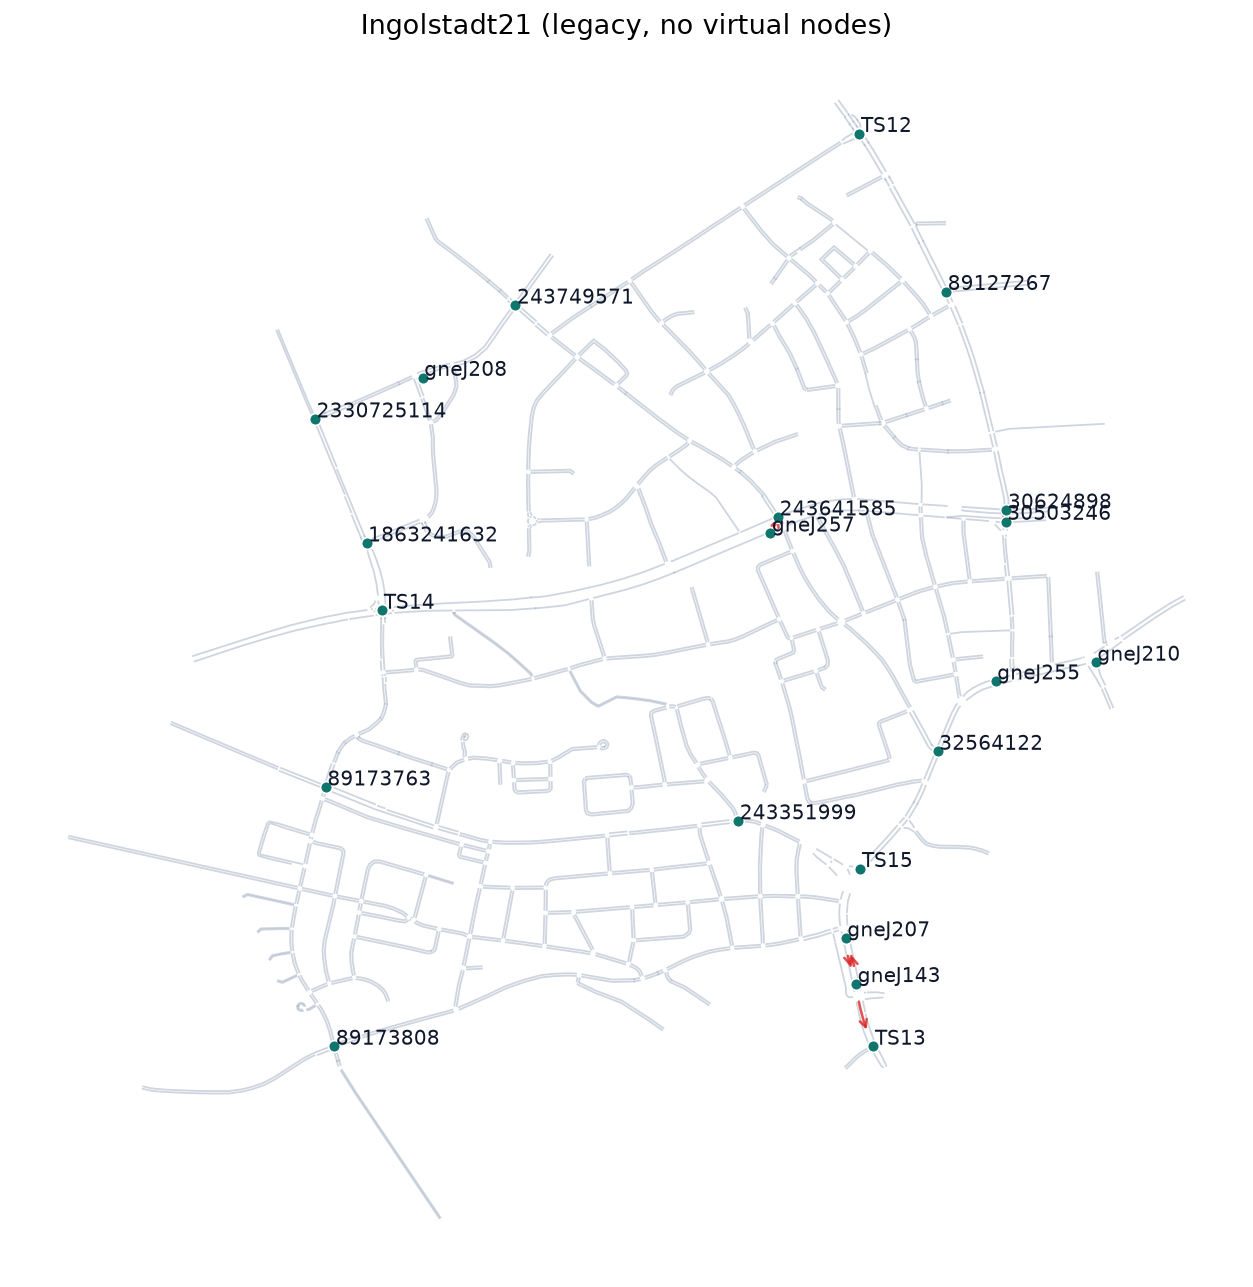

<Figure size 832x624 with 0 Axes>

(<Figure size 1560x1300 with 1 Axes>, <Figure size 1300x1170 with 2 Axes>)

In [13]:
# Plot the legacy graph constructor without virtual nodes and its adjacency matrix.
from sumo_rl.models.graph import _legacy_build_traffic_signal_graph, traffic_signals_from_base_env

legacy_graph = _legacy_build_traffic_signal_graph(
    traffic_signals_from_base_env(base_env),
    include_virtual_nodes=False,
    add_self_loops=ADD_SELF_LOOPS,
    feature_layout="phase_min_green_density_queue",
)
legacy_positions = traffic_signal_positions(net, base_env, list(legacy_graph.ts_ids))
plot_graph_and_adjacency(
    legacy_graph,
    legacy_positions,
    SCENARIO_NAME,
    display_virtual_nodes=False,
    title_suffix="(legacy, no virtual nodes)",
)


In [14]:
# Run this cell when you are done with the notebook session.
graph_env.close()